# Permutation importance

Ejemplo desarrollado con código propio. El objetivo es demostrar que a veces quitar columnas ruidosas es beneficioso, se pueden conseguir resultados similares o incluso mejores con mayor tolerancia y menor sobreajuste.  


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score # métrica de evaluación
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np
from zipfile import ZipFile
import sys
sys.path.append('../Code')
from SBS import SBS
from sklearn import metrics
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Para estandarizar las figuras
figsize     = (8, 5)
test_size   = 0.15
cv          = 4
ks          = np.arange(1, 50, 2)

El dataset tiene información de sensores. Cada número representa la energía dentro de una banda de frecuencia particular integrada durante un cierto período de tiempo.  
El target es R=Roca o M=Mina, considero a Mina la clase de interés (1).

In [2]:
# Ruta al archivo ZIP
fname = "../datasets/connectionist+bench+sonar+mines+vs+rocks.zip"
with ZipFile(fname) as archivo_zip:
    with archivo_zip.open("sonar.all-data") as archivo:
        df = pd.read_csv(archivo, header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [3]:
df.shape

(208, 61)

El dataset es muy "ancho", es decir, tiene muchas variables para la cantidad de registros. Entre otros problemas es esperable que variabilidad en las mediciones. Si no hay tantos datos las muestras de test o validación serán pequeñas y  es lógico que el azar en la selección de muestras tengan alto impacto.

## Breve EDA y procesamiento de datos

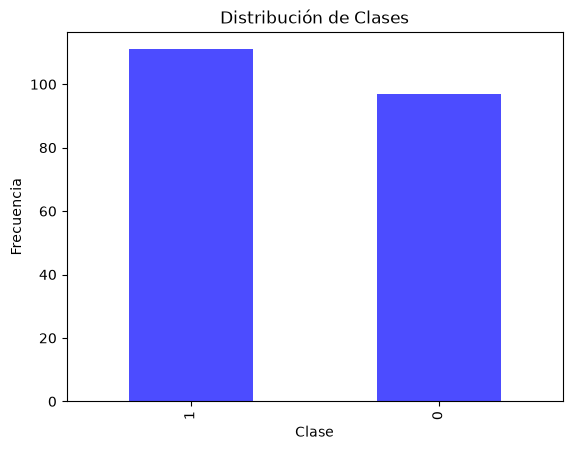

In [3]:
df["target"] = df[60].map({"R": 0, "M": 1}).astype("uint8")
df.drop(columns=[60], inplace=True)         
df["target"].value_counts().plot(kind="bar", color="blue", alpha=0.7)
plt.title("Distribución de Clases")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")    
plt.show()

Dataset sin nulo, que belleza!

In [4]:
df.isna().sum() # Verificar si hay valores nulos

0         0
1         0
2         0
3         0
4         0
         ..
56        0
57        0
58        0
59        0
target    0
Length: 61, dtype: int64

Separo el target. Todas las columnas forman parte de esta primera parte

In [5]:
X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=SEED)


Escalo los datos. Ojo con la fuga! 

In [6]:

X_train_scl = X_train.copy()
X_test_scl = X_test.copy() 
#Perdi los nombres de las columnas
ss = StandardScaler()
ss.fit(X_train)
X_train_scl = ss.transform(X_train)
X_test_scl  = ss.transform(X_test)  

### Intento clasificar Roca o Mina con todas las características

Mediante regla del codo y validacion cruzada (como corresponde) selecciono el óptimo de k

In [7]:
acus    = []
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    # internamente hace fit y predict!
    cvs = cross_val_score(knn, X_train_scl, y_train, cv=cv, scoring='accuracy')
    acus.append(cvs)


¿Y la muestra de test? Esa queda para una segunda validación

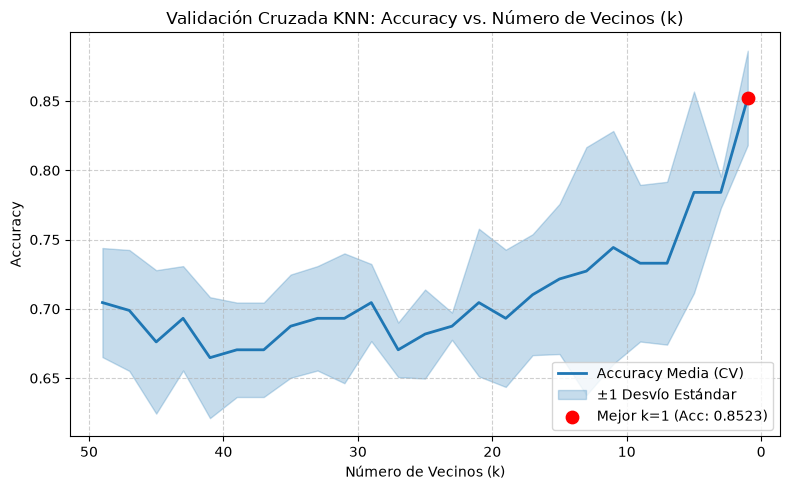

In [8]:
acus_arr = np.array(acus)
means = np.mean(acus_arr, axis=1)
stds  = np.std(acus_arr, axis=1)
plt.figure(figsize=figsize)
plt.plot(ks, means, label='Accuracy Media (CV)', color='#1f77b4', linewidth=2)
plt.fill_between(ks, means - stds, means + stds, alpha=0.25, color='#1f77b4', label='±1 Desvío Estándar')
best_idx = np.argmax(means)
plt.scatter(ks[best_idx], means[best_idx], color='red', s=80, zorder=5,
            label=f'Mejor k={ks[best_idx]} (Acc: {means[best_idx]:.4f})')
plt.gca().invert_xaxis()

plt.title('Validación Cruzada KNN: Accuracy vs. Número de Vecinos (k)')
plt.xlabel('Número de Vecinos (k)')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

A ojo, determino alrededor de 3. El valor de muy bajo, peligro inminente de sobreajuste. Veamos las curvas de validación.

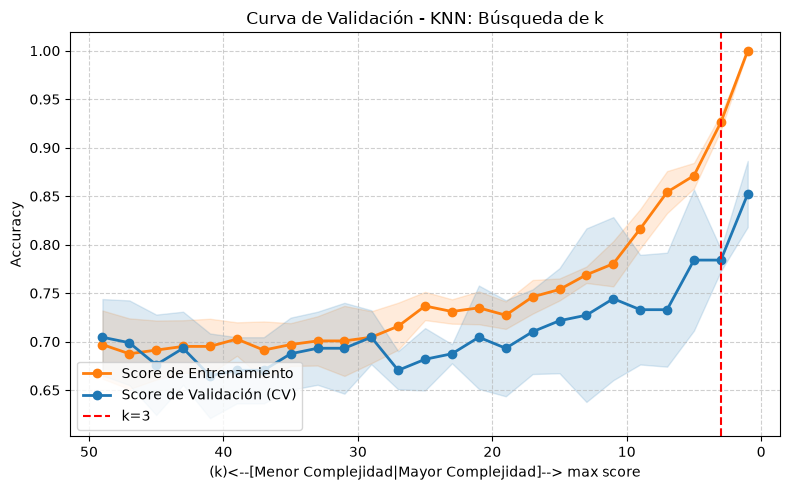

In [9]:
train_scores, test_scores = validation_curve(
    estimator=KNeighborsClassifier(),
    X=X_train_scl,
    y=y_train,
    param_name='n_neighbors',
    param_range=ks,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
test_mean  = np.mean(test_scores, axis=1)
test_std   = np.std(test_scores, axis=1)

plt.figure(figsize=figsize)
plt.plot(ks, train_mean, 'o-', color='tab:orange', linewidth=2, label='Score de Entrenamiento')
plt.fill_between(ks, train_mean - train_std, train_mean + train_std, alpha=0.15, color='tab:orange')

plt.plot(ks, test_mean, 'o-', color='tab:blue', linewidth=2, label='Score de Validación (CV)')
plt.fill_between(ks, test_mean - test_std, test_mean + test_std, alpha=0.15, color='tab:blue')
plt.axvline(3, color='red', linestyle='--', label='k=3')
plt.gca().invert_xaxis()

plt.title('Curva de Validación - KNN: Búsqueda de k')
plt.xlabel(f'(k)<--[Menor Complejidad|Mayor Complejidad]--> max score')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

Yo en 31-33 ya veo que comienza la separación, me parece un valor razonable. ¿Podría ser un poco menos? Si, pero preferible ser conservador y ademas al final del notebook hay mas razones para ser justos y seleccionar este valor.

In [10]:
model = KNeighborsClassifier(n_neighbors=33)
model.fit(X_train_scl, y_train)
y_pred = model.predict(X_test_scl)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.69      0.75        13
           1       0.81      0.89      0.85        19

    accuracy                           0.81        32
   macro avg       0.81      0.79      0.80        32
weighted avg       0.81      0.81      0.81        32



33 parece un valor razonable y el accuracy es de 0.81 ¿Sera mejorable?

Hagamos un "Permutation importance" a ver que sale. Inicialmente voy a usar biblioteca 

In [11]:
ascore = accuracy_score(y_test, y_pred)
print(f"Accuracy en el conjunto de prueba: {ascore:.4f}")


Accuracy en el conjunto de prueba: 0.8125


In [12]:
model = KNeighborsClassifier(n_neighbors=33)
model.fit(X_train, y_train)
result = permutation_importance(estimator=model, X=X_train_scl, y=y_train, n_repeats=100, random_state=0)

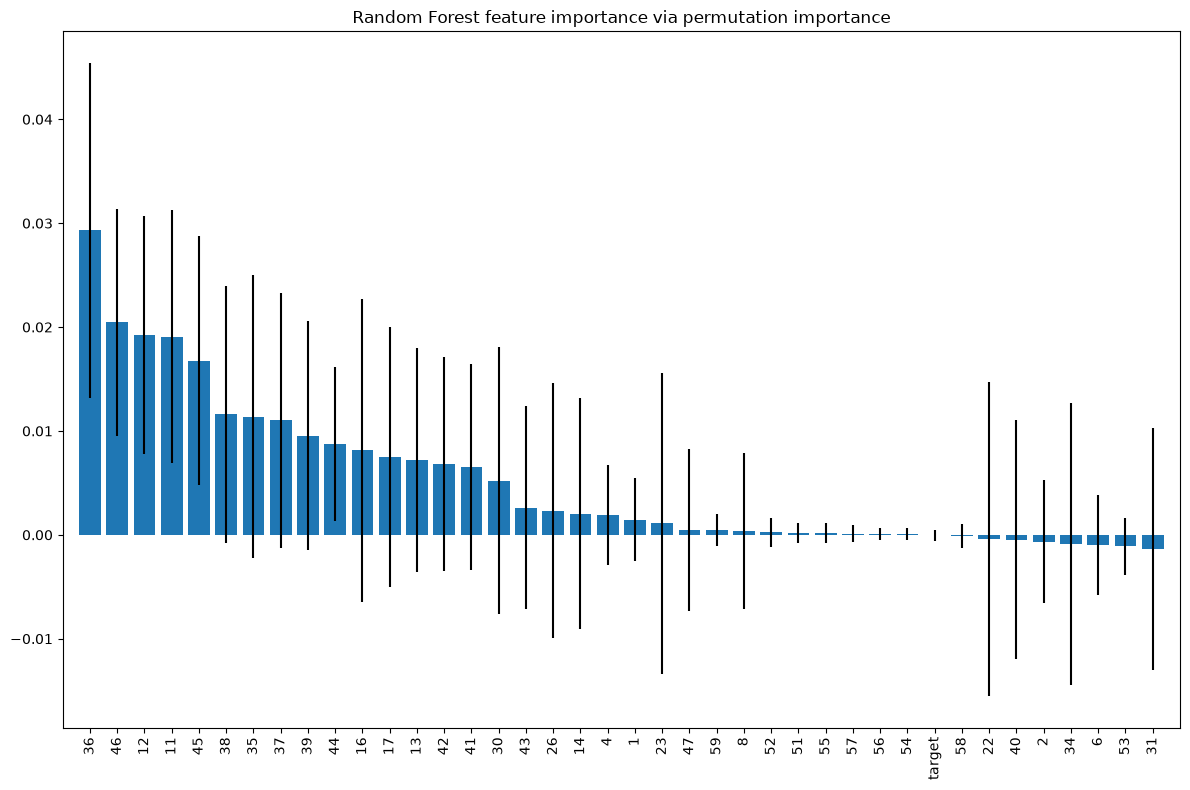

In [13]:
amax = 40
indices = np.argsort(result['importances_mean'])[::-1][:amax]

plt.figure(figsize=(12, 8))
plt.title("Random Forest feature importance via permutation importance")
plt.bar(
    range(amax),
    result['importances_mean'][indices],
    yerr=result['importances_std'][indices]
)

feature_names = np.array(list(df.columns[1:])+['random'])
plt.xticks(range(amax), feature_names[indices], rotation=90)
plt.xlim([-1, amax])
#plt.ylim([0, 0.2])

plt.tight_layout()
plt.show()


In [14]:
n_features = 15
indices = np.argsort(result['importances_mean'])[::-1]
indices[:n_features]

array([35, 45, 11, 10, 44, 37, 34, 36, 38, 43, 15, 16, 12, 41, 40])

-------------------------------------

Ahora me quedo con n_features

In [15]:
X_train.iloc[:, list(indices[:n_features])].head()

,35,45,11,10,44,37,34,36,38,43,15,16,12,41,40
66,0.9348,0.0508,0.2060,0.0327,0.1512,0.5733,0.9885,0.6960,0.5872,0.1997,0.2232,0.2070,0.1908,0.5247,0.5651
120,0.1613,0.1216,0.2390,0.1809,0.1625,0.3390,0.0946,0.2824,0.3019,0.2069,0.5325,0.5486,0.2947,0.2676,0.2978
147,0.0704,0.5649,0.1377,0.2128,0.5438,0.3941,0.2960,0.0970,0.6028,0.4164,0.4331,0.5954,0.4032,0.4808,0.3924
98,0.4577,0.2246,0.2259,0.2907,0.2811,0.3372,0.2896,0.3725,0.3803,0.1951,0.3956,0.4386,0.3136,0.2711,0.3603
138,0.4219,0.2134,0.3160,0.1739,0.1192,0.2483,0.0223,0.5496,0.2034,0.0807,0.2580,0.1796,0.3249,0.4463,0.2837


--------------------

Veamos si realmente es cierto arrancando de 0

Me quedo con las columnas seleccionadas

In [16]:
features = X_train.iloc[:, list(indices[:n_features])].columns

Arranco de 0 con todo

In [17]:

# Ruta al archivo ZIP
fname = "../datasets/connectionist+bench+sonar+mines+vs+rocks.zip"
with ZipFile(fname) as archivo_zip:
    with archivo_zip.open("sonar.all-data") as archivo:
        df = pd.read_csv(archivo, header=None)

df["target"] = df[60].map({"R": 0, "M": 1}).astype("uint8")
df.drop(columns=[60], inplace=True)   
df = df[features.tolist() + ['target']]  # Mantener solo las columnas seleccionadas y la columna objetivo


In [18]:

X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=SEED)

#Perdi los nombres de las columnas
ss = StandardScaler()
ss.fit(X_train)
X_train_scl = ss.transform(X_train)
X_test_scl  = ss.transform(X_test) 


acus    = []
ks      = np.arange(3, 81, 2)
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    # internamente hace fit y predict!
    cvs = cross_val_score(knn, X_train_scl, y_train, cv=cv, scoring='accuracy')

    acus.append(cvs)

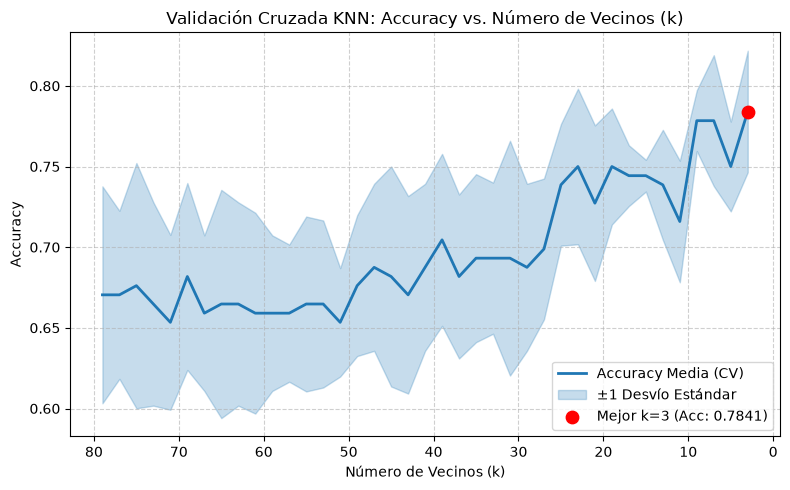

In [19]:
acus_arr = np.array(acus)
means = np.mean(acus_arr, axis=1)
stds  = np.std(acus_arr, axis=1)

plt.figure(figsize=figsize)
plt.plot(ks, means, label='Accuracy Media (CV)', color='#1f77b4', linewidth=2)
plt.fill_between(ks, means - stds, means + stds, alpha=0.25, color='#1f77b4', label='±1 Desvío Estándar')
best_idx = np.argmax(means)
plt.scatter(ks[best_idx], means[best_idx], color='red', s=80, zorder=5,
            label=f'Mejor k={ks[best_idx]} (Acc: {means[best_idx]:.4f})')
plt.gca().invert_xaxis()

plt.title('Validación Cruzada KNN: Accuracy vs. Número de Vecinos (k)')
plt.xlabel('Número de Vecinos (k)')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

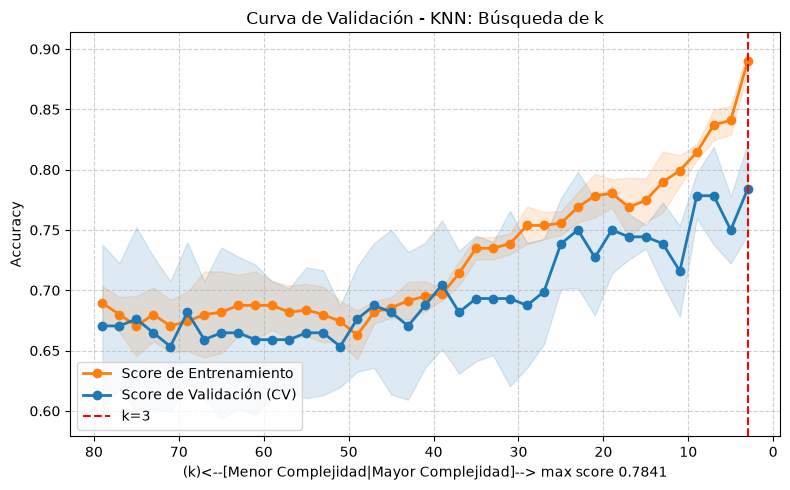

In [20]:
train_scores, test_scores = validation_curve(
    estimator=KNeighborsClassifier(),
    X=X_train_scl,
    y=y_train,
    param_name='n_neighbors',
    param_range=ks,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
test_mean  = np.mean(test_scores, axis=1)
test_std   = np.std(test_scores, axis=1)

plt.figure(figsize=figsize)
plt.plot(ks, train_mean, 'o-', color='tab:orange', linewidth=2, label='Score de Entrenamiento')
plt.fill_between(ks, train_mean - train_std, train_mean + train_std, alpha=0.15, color='tab:orange')

plt.plot(ks, test_mean, 'o-', color='tab:blue', linewidth=2, label='Score de Validación (CV)')
plt.fill_between(ks, test_mean - test_std, test_mean + test_std, alpha=0.15, color='tab:blue')
plt.axvline(3, color='red', linestyle='--', label='k=3')
plt.gca().invert_xaxis()

plt.title('Curva de Validación - KNN: Búsqueda de k')
plt.xlabel(f'(k)<--[Menor Complejidad|Mayor Complejidad]--> max score {test_mean.max():.4f}')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

Con menos columnas podria animarme a un modelo mas complejo, pero voy a mantener el k.

In [21]:
model = KNeighborsClassifier(n_neighbors=33)
model.fit(X_train_scl, y_train)
y_pred = model.predict(X_test_scl)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.77      0.80        13
           1       0.85      0.89      0.87        19

    accuracy                           0.84        32
   macro avg       0.84      0.83      0.84        32
weighted avg       0.84      0.84      0.84        32



Obtuve un accuracy de 0.84 contra 0.81, no solo mejora tambien tiene con menos características